Loading the data processed by hdWGCNA in R

In [1]:
import math
import seaborn as sns
import numpy as np
import scanpy as sc
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from abc_atlas_access.abc_atlas_cache.abc_project_cache import AbcProjectCache

In [2]:
# Loading AnnData object
base_path = Path("/data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/")
expr_path = base_path / "AnnData/WMB-10Xv3-Isocortex-1-raw-wmeta-IT-ET-Glut.h5ad"
adata = sc.read_h5ad(expr_path)
adata

AnnData object with n_obs × n_vars = 121827 × 32285
    obs: 'cell_barcode', 'barcoded_cell_sample_label', 'library_label', 'feature_matrix_label', 'entity', 'brain_section_label', 'library_method', 'region_of_interest_acronym', 'donor_label', 'donor_genotype', 'donor_sex', 'dataset_label', 'x', 'y', 'cluster_alias', 'neurotransmitter', 'class', 'subclass', 'supertype', 'cluster', 'neurotransmitter_color', 'class_color', 'subclass_color', 'supertype_color', 'cluster_color', 'region_of_interest_order', 'region_of_interest_color'
    var: 'gene_symbol'

In [3]:
# Loading Module Eigengenes dataframe
select_region = "Glut"
base_path = Path("/data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/outputs")
modules_df = pd.read_csv(base_path / f"WMB-10Xv3-{select_region}-raw-mc-wgcna-modules.csv", index_col="Unnamed: 0")
modules_df.head()

,gene_name,module,color,kME_grey,kME_Glut-M1,kME_Glut-M2,kME_Glut-M3,kME_Glut-M4,kME_Glut-M5,kME_Glut-M6,kME_Glut-M7
ENSMUSG00000043659,ENSMUSG00000043659,grey,grey,-0.041859,0.025588,-0.041061,0.045359,0.147245,0.149132,-0.024783,-0.112368
ENSMUSG00000108532,ENSMUSG00000108532,Glut-M1,green,0.113287,0.406982,-0.137795,0.194830,-0.008591,0.047679,-0.136549,0.111784
ENSMUSG00000005716,ENSMUSG00000005716,Glut-M2,yellow,0.010592,-0.005589,0.187729,-0.070545,0.166084,0.012317,-0.017360,-0.081384
ENSMUSG00000053475,ENSMUSG00000053475,grey,grey,0.428535,-0.017418,-0.017903,0.066508,0.000075,-0.040867,-0.068429,0.102690
ENSMUSG00000053153,ENSMUSG00000053153,Glut-M3,blue,-0.012413,0.060220,-0.081600,0.234277,0.029518,0.041267,-0.050567,0.003529


In [4]:
# Loading Module Eigengenes dataframe
base_path = Path("/data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/outputs")
MEs_df = pd.read_csv(base_path / f"WMB-10Xv3-{select_region}-raw-mc-wgcna-MEs.csv", index_col="Unnamed: 0")
MEs_df = MEs_df.drop(columns=["grey"])
MEs_df.head()

,yellow,black,green,brown,turquoise,blue,red
GCACTAAGTACAAGTA-399_B02,-3.821411,-4.533124,0.676653,8.477648,4.209102,2.058199,0.697344
CAGAGCCGTCCTGGTG-399_A02,-4.291907,-5.768826,0.695967,7.667619,0.398596,0.201277,-1.823024
CGCCATTCACGACAGA-403_A06,-0.539992,-4.500186,1.186601,8.883785,0.712270,-2.292395,-3.073647
GGGTTTATCCGATCGG-399_B02,-5.433339,-5.344072,2.706242,8.468793,2.545302,1.557324,-3.601804
GTGTGATCAGACAAAT-399_B02,-1.990233,-5.771111,0.710428,7.406711,0.170618,-0.801608,-4.295843


In [5]:
# Create a mapping from color to module
color_to_module = modules_df.set_index("color")["module"].to_dict()

# Rename the columns of MEs_df
MEs_df.rename(columns=color_to_module, inplace=True)

# Sort the columns of MEs_df alphabetically
MEs_df = MEs_df.reindex(sorted(MEs_df.columns), axis=1)
MEs_df.head()

,Glut-M1,Glut-M2,Glut-M3,Glut-M4,Glut-M5,Glut-M6,Glut-M7
GCACTAAGTACAAGTA-399_B02,0.676653,-3.821411,2.058199,4.209102,8.477648,-4.533124,0.697344
CAGAGCCGTCCTGGTG-399_A02,0.695967,-4.291907,0.201277,0.398596,7.667619,-5.768826,-1.823024
CGCCATTCACGACAGA-403_A06,1.186601,-0.539992,-2.292395,0.712270,8.883785,-4.500186,-3.073647
GGGTTTATCCGATCGG-399_B02,2.706242,-5.433339,1.557324,2.545302,8.468793,-5.344072,-3.601804
GTGTGATCAGACAAAT-399_B02,0.710428,-1.990233,-0.801608,0.170618,7.406711,-5.771111,-4.295843


In [6]:
# Getting the list of modules
modules = MEs_df.columns.tolist()

In [7]:
# Adding MEs to AnnData object
merged_df = pd.merge(adata.obs, MEs_df, left_index=True, right_index=True)
merged_df.head()

,cell_barcode,barcoded_cell_sample_label,library_label,feature_matrix_label,entity,brain_section_label,library_method,region_of_interest_acronym,donor_label,donor_genotype,...,cluster_color,region_of_interest_order,region_of_interest_color,Glut-M1,Glut-M2,Glut-M3,Glut-M4,Glut-M5,Glut-M6,Glut-M7
GCACTAAGTACAAGTA-399_B02,GCACTAAGTACAAGTA,399_B02,L8TX_201022_01_H06,WMB-10Xv3-Isocortex-1,cell,NaN,10Xv3,RSP,Snap25-IRES2-Cre;Ai14-546810,Snap25-IRES2-Cre/wt;Ai14(RCL-tdT)/wt,...,#99CFFF,11,#E4FF26,0.676653,-3.821411,2.058199,4.209102,8.477648,-4.533124,0.697344
CAGAGCCGTCCTGGTG-399_A02,CAGAGCCGTCCTGGTG,399_A02,L8TX_201023_01_A09,WMB-10Xv3-Isocortex-1,cell,NaN,10Xv3,RSP,Snap25-IRES2-Cre;Ai14-546810,Snap25-IRES2-Cre/wt;Ai14(RCL-tdT)/wt,...,#99CFFF,11,#E4FF26,0.695967,-4.291907,0.201277,0.398596,7.667619,-5.768826,-1.823024
CGCCATTCACGACAGA-403_A06,CGCCATTCACGACAGA,403_A06,L8TX_201022_01_B07,WMB-10Xv3-Isocortex-1,cell,NaN,10Xv3,RSP,Snap25-IRES2-Cre;Ai14-547057,Snap25-IRES2-Cre/wt;Ai14(RCL-tdT)/wt,...,#99CFFF,11,#E4FF26,1.186601,-0.539992,-2.292395,0.712270,8.883785,-4.500186,-3.073647
GGGTTTATCCGATCGG-399_B02,GGGTTTATCCGATCGG,399_B02,L8TX_201022_01_H06,WMB-10Xv3-Isocortex-1,cell,NaN,10Xv3,RSP,Snap25-IRES2-Cre;Ai14-546810,Snap25-IRES2-Cre/wt;Ai14(RCL-tdT)/wt,...,#99CFFF,11,#E4FF26,2.706242,-5.433339,1.557324,2.545302,8.468793,-5.344072,-3.601804
GTGTGATCAGACAAAT-399_B02,GTGTGATCAGACAAAT,399_B02,L8TX_201022_01_H06,WMB-10Xv3-Isocortex-1,cell,NaN,10Xv3,RSP,Snap25-IRES2-Cre;Ai14-546810,Snap25-IRES2-Cre/wt;Ai14(RCL-tdT)/wt,...,#99CFFF,11,#E4FF26,0.710428,-1.990233,-0.801608,0.170618,7.406711,-5.771111,-4.295843


## Cell labels

In [14]:
from matplotlib.lines import Line2D

def plot_labels(xx, yy, cc=None, val=None, label_column=None, fig_width=10, fig_height=6, cmap=None):
    # Initialize plot with constrained layout to prevent overlap
    fig, ax = plt.subplots(constrained_layout=True)
    fig.set_size_inches(fig_width, fig_height)
    
    # Plot the data
    if cmap is not None:
        scatter = ax.scatter(xx, yy, s=0.5, c=val, marker='.', cmap=cmap)
    elif cc is not None:
        scatter = ax.scatter(xx, yy, s=0.5, color=cc, marker='.')
    else:
        scatter = ax.scatter(xx, yy, s=0.5, marker='.')
    
    # Set axis properties
    # ax.axis('equal')
    # ax.set_xlim(-18, 27)
    # ax.set_ylim(-18, 27)
    ax.set_xticks([])
    ax.set_yticks([])
    
    # Add legend if label_column is provided
    if label_column is not None:
        # Create DataFrame for unique label-color pairs
        df_legend = pd.DataFrame({'label': label_column, 'color': cc}).drop_duplicates().sort_values('label')
        
        # Create legend handles
        legend_elements = [
            Line2D([0], [0], 
                   marker='o', 
                   color='w', 
                   label=row['label'],
                   markerfacecolor=row['color'], 
                   markersize=8)
            for _, row in df_legend.iterrows()
        ]
        
        # Add legend outside the plot (adjust bbox_to_anchor as needed)
        ax.legend(
            handles=legend_elements, 
            title="Legend", 
            loc="upper left",  # Anchor point for the legend
            bbox_to_anchor=(1.05, 1)  # Shift legend to the right of the plot
        )
    
    return fig, ax

(<Figure size 1000x600 with 1 Axes>, <Axes: >)

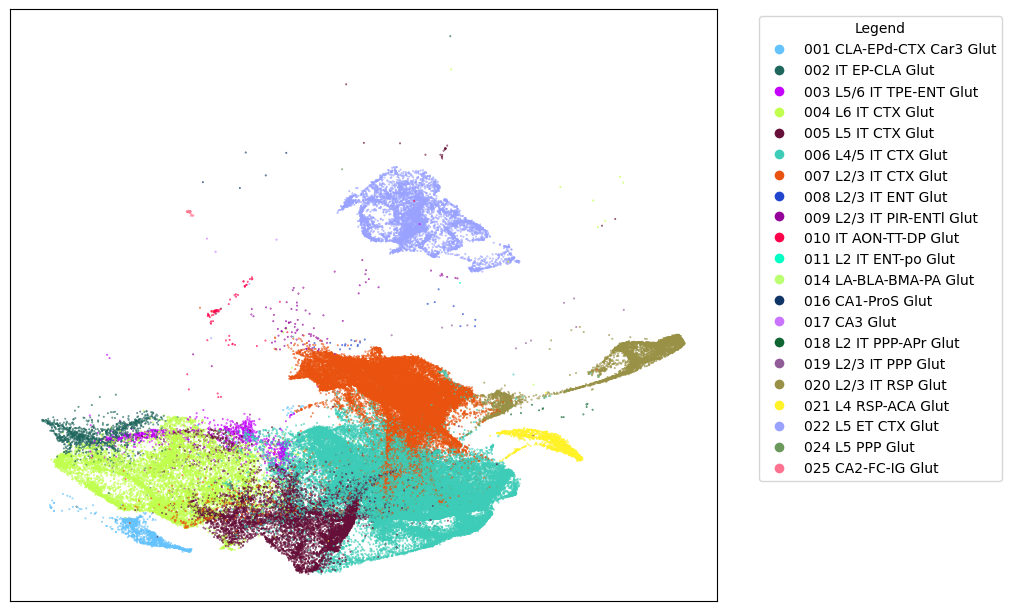

In [15]:
plot_labels(adata.obs['x'], adata.obs['y'], cc=adata.obs['subclass_color'], label_column=adata.obs['subclass'])

## Module Eigengene activation in UMAP

In [16]:
def plot_umap(data, x_col="x", y_col="y", color_col="turquoise", fig_width=10, fig_height=6, cmap="viridis"):
    """
    Plots a UMAP visualization with a style similar to a minimal scatter plot.

    Parameters:
        data (pd.DataFrame): The dataframe containing UMAP coordinates and the column to color.
        x_col (str): Column name for the x-axis UMAP coordinate.
        y_col (str): Column name for the y-axis UMAP coordinate.
        color_col (str): Column name for the color values.
        fig_width (float): Width of the figure.
        fig_height (float): Height of the figure.
        cmap (str): Colormap for the scatter plot.

    Returns:
        fig, ax: Matplotlib figure and axis objects.
    """
    fig, ax = plt.subplots()
    fig.set_size_inches(fig_width, fig_height)

    # Scatter plot with small marker size
    scatter = ax.scatter(
        data[x_col],
        data[y_col],
        s=0.5,
        c=data[color_col],
        cmap=cmap,
        marker='.',
        edgecolor='none'
    )

    # Set equal axis aspect ratio
    ax.axis('equal')
    ax.set_xticks([])
    ax.set_yticks([])

    # Add a colorbar
    fig.colorbar(scatter, ax=ax, orientation='vertical', label=color_col)

    return fig, ax

(<Figure size 1000x600 with 2 Axes>, <Axes: >)

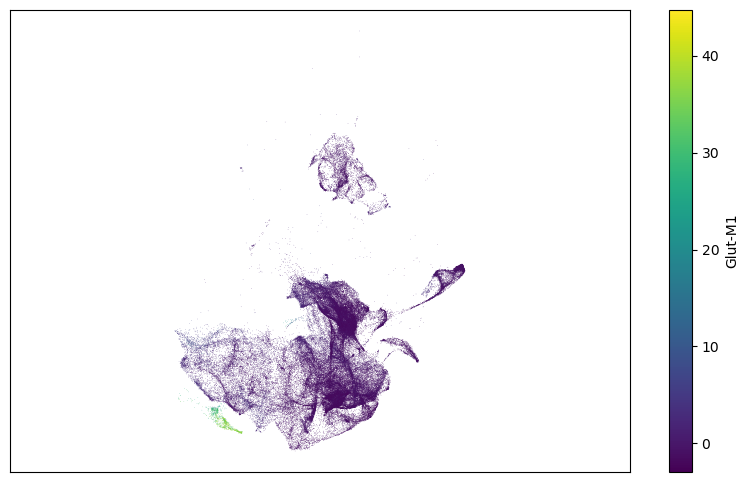

In [17]:
plot_umap(merged_df, color_col="Glut-M1")

In [18]:
def plot_multiple_umaps(data, modules, x_col="x", y_col="y", fig_width=10, fig_height=6, cmap="viridis"):
    """
    Plots multiple UMAP visualizations for the specified modules.

    Parameters:
        data (pd.DataFrame): The dataframe containing UMAP coordinates and the module eigengenes.
        modules (list): List of module names to plot.
        x_col (str): Column name for the x-axis UMAP coordinate.
        y_col (str): Column name for the y-axis UMAP coordinate.
        fig_width (float): Width of each subplot.
        fig_height (float): Height of each subplot.
        cmap (str): Colormap for the scatter plots.

    Returns:
        None
    """
    n_cols = 3  # Number of columns for subplots
    n_rows = math.ceil(len(modules) / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_width * n_cols, fig_height * n_rows))
    axes = axes.flatten()

    for i, module in enumerate(modules):
        ax = axes[i]
        scatter = ax.scatter(
            data[x_col],
            data[y_col],
            s=0.5,
            c=data[module],
            cmap=cmap,
            marker='.',
            edgecolor='none'
        )

        ax.axis('equal')
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(module)

        fig.colorbar(scatter, ax=ax, orientation='vertical', label=module)

    # Turn off unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

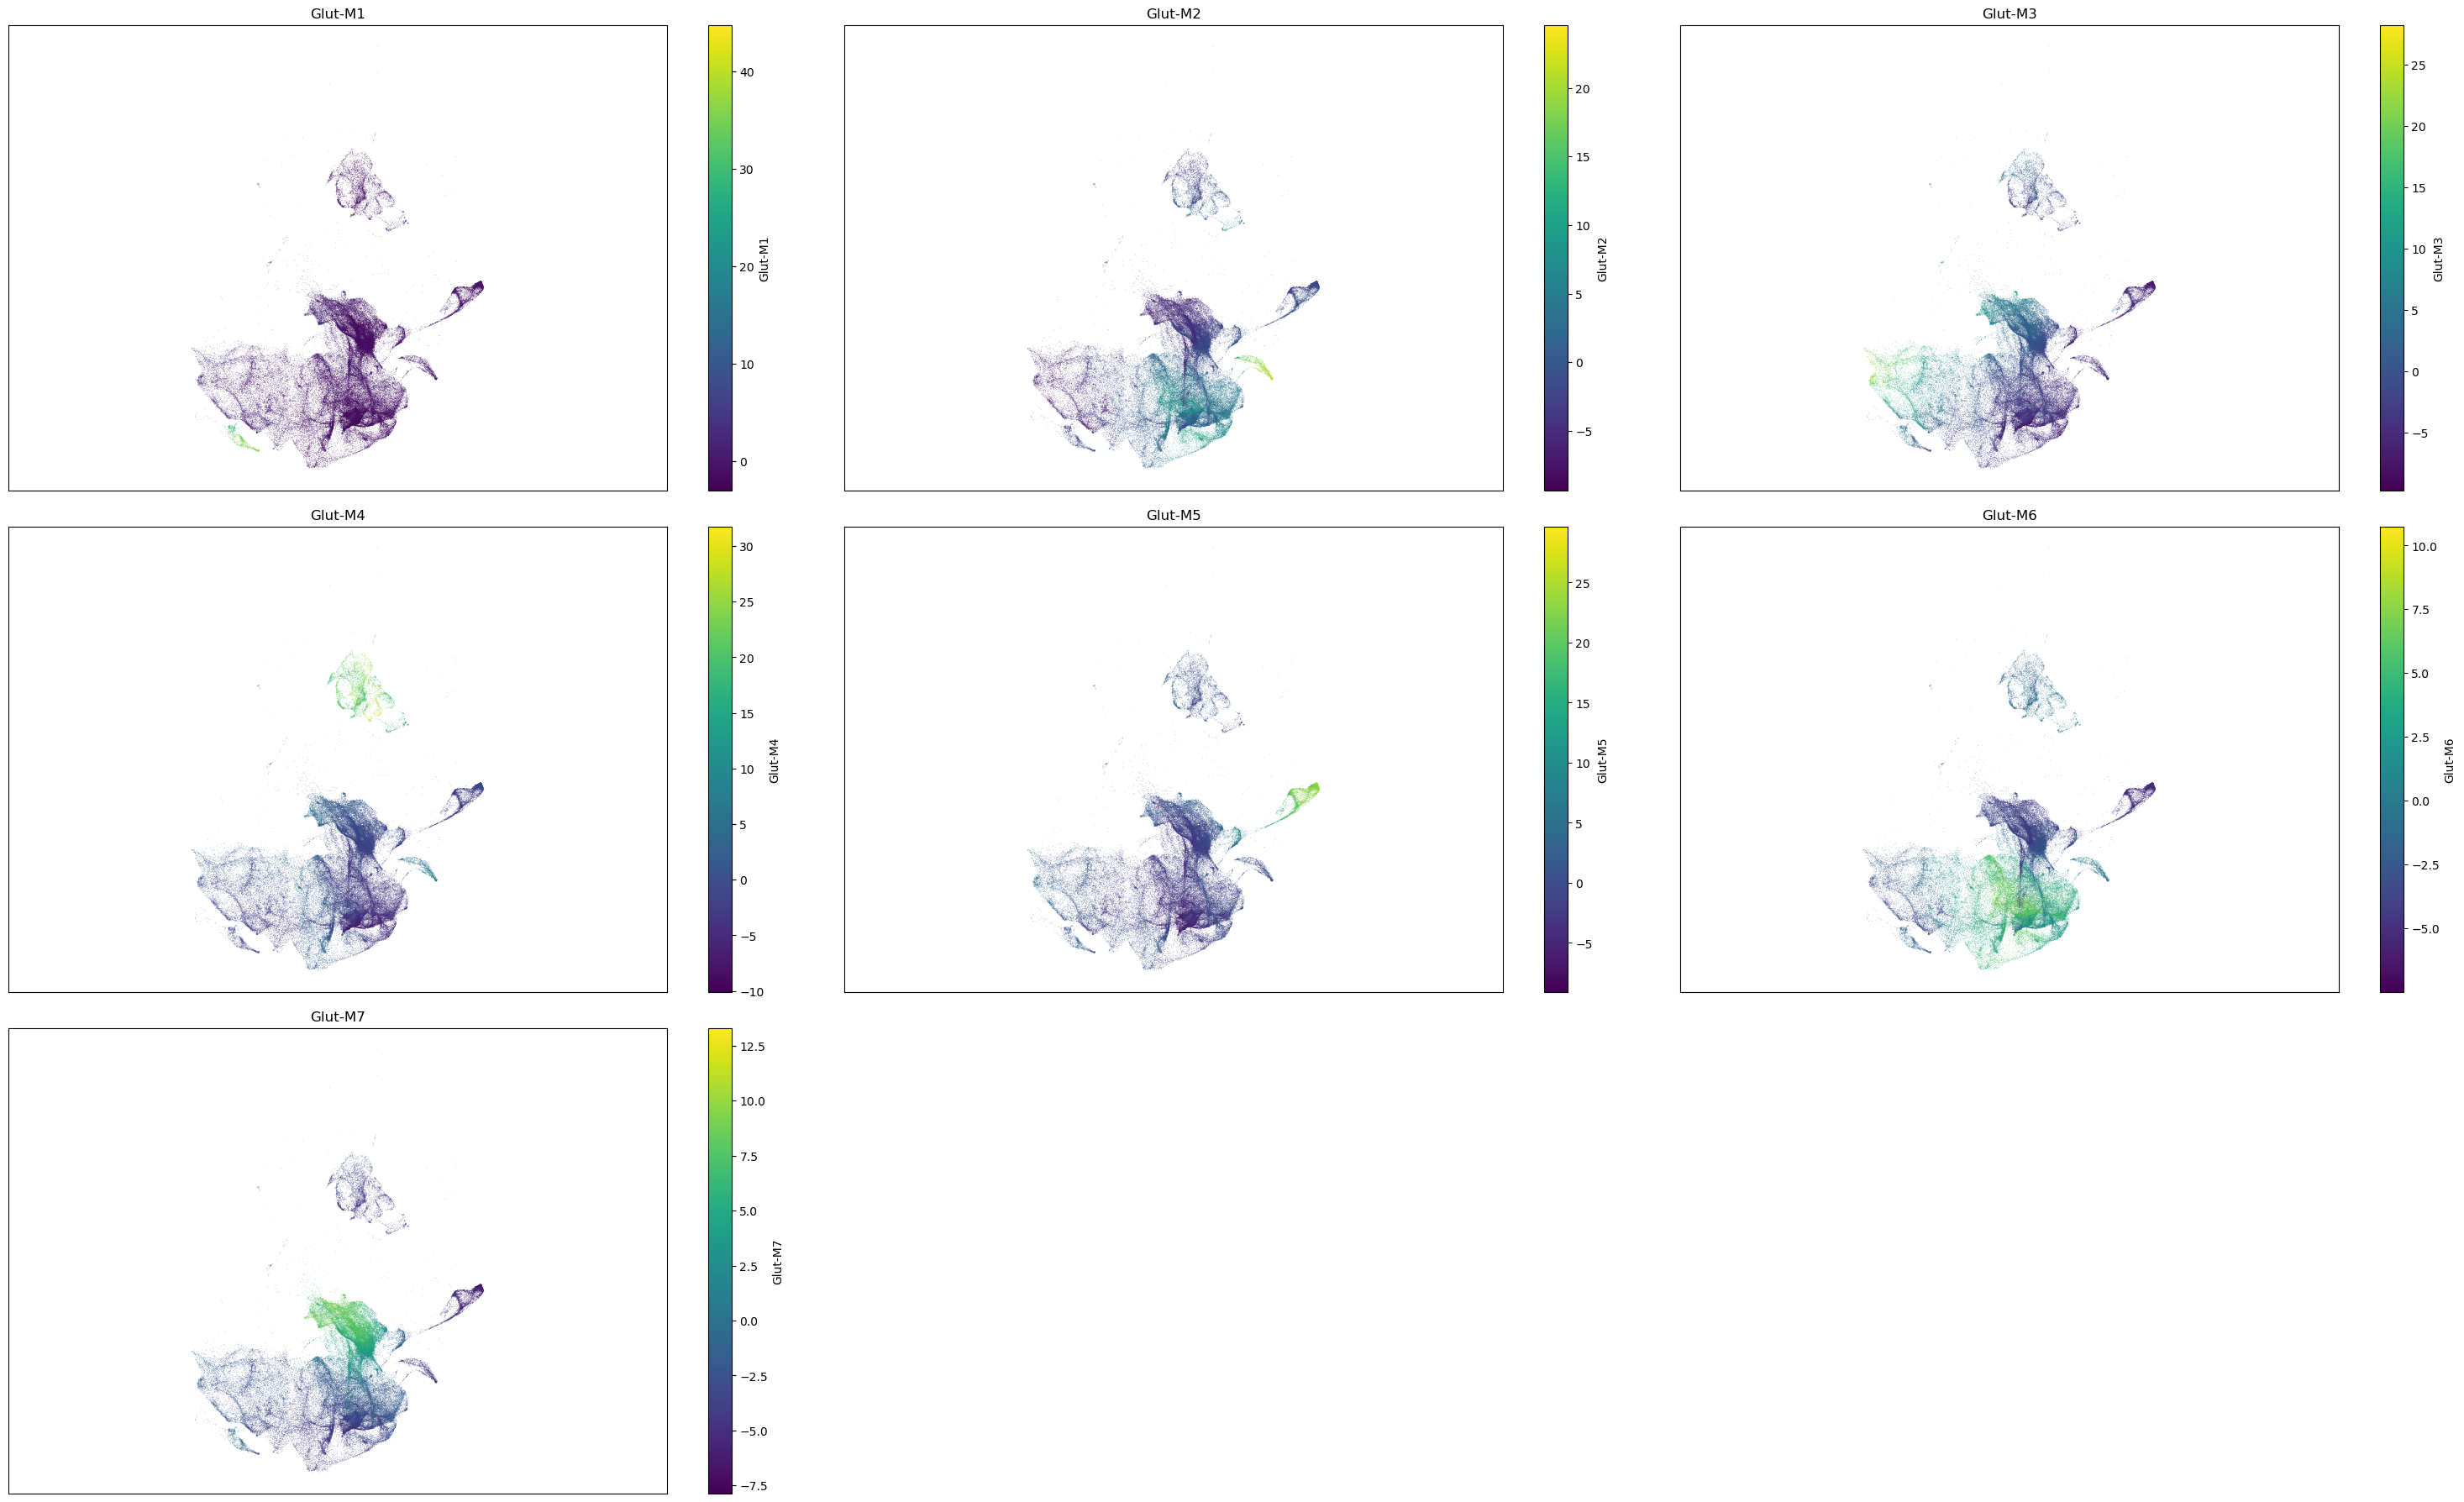

In [19]:
plot_multiple_umaps(merged_df, modules)

## Module Eigengenes across cell classes

In [20]:
# Convert to AnnData (required for scanpy plotting)
adata_vis = sc.AnnData(merged_df[modules])
adata_vis.obs["subclass"] = merged_df["subclass"]  # Add cell type labels

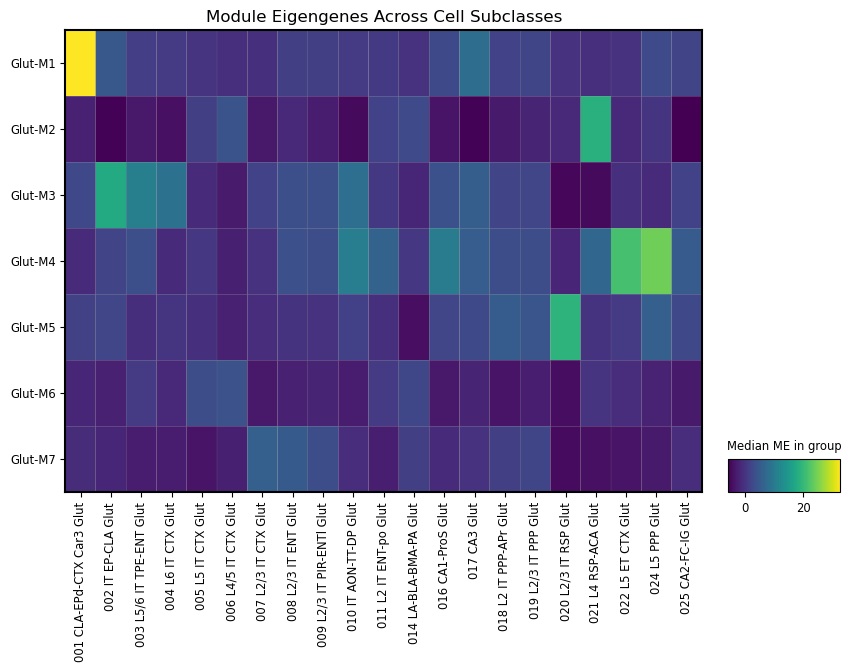

In [21]:
# Matrixplot
sc.pl.matrixplot(
    adata_vis,
    var_names=modules,
    groupby="subclass",
    swap_axes=True,  # Show modules on y-axis, cell types on x-axis
    figsize=(10, 6),  # Adjust size as needed
    title="Module Eigengenes Across Cell Subclasses",
    colorbar_title="Median ME in group",
    cmap="viridis",  # Color map
    dendrogram=False,  # Disable clustering for simplicity
    use_raw=False,
)

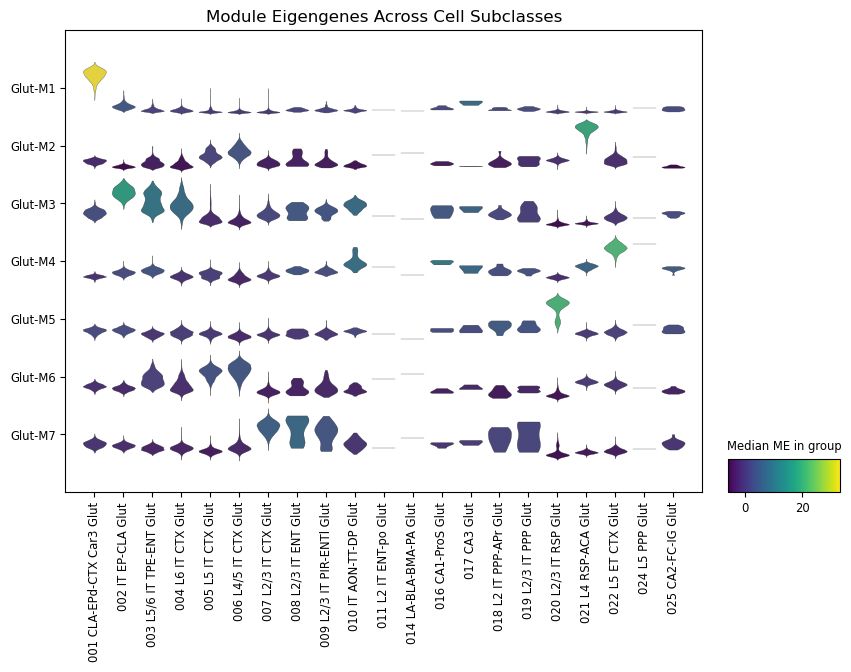

In [22]:
# Plot stacked violins
sc.pl.stacked_violin(
    adata_vis,
    var_names=modules,
    groupby="subclass",
    swap_axes=True,  # Show modules on y-axis, cell types on x-axis
    figsize=(10, 6),  # Adjust size as needed
    title="Module Eigengenes Across Cell Subclasses",
    colorbar_title="Median ME in group",
    cmap="viridis",  # Color map
    dendrogram=False,  # Disable clustering for simplicity
    use_raw=False,
)

# Quantifying module specificity

In [23]:
tau_scores = {}

for module in modules:
    tau_df = merged_df[["subclass", module]].copy()
    tau_df[module] = tau_df[module] - tau_df[module].min() + 1e-6  # Shift the eigengene values to ensure non-negativity

    # Compute average eigengene per cell class
    avg_expression = tau_df.groupby('subclass', observed=False)[module].mean()

    # Normalize by the maximum average expression
    max_expr = avg_expression.max()
    normalized_expr = avg_expression / max_expr

    # Compute tau score
    tau = np.sum(1 - normalized_expr) / (len(normalized_expr) - 1)
    tau_scores[module] = tau

# Print Tau scores for all modules
for module, score in tau_scores.items():
    print(f"Tau specificity score for {module} module: {score:.3f}")

Tau specificity score for Glut-M1 module: 0.879
Tau specificity score for Glut-M2 module: 0.741
Tau specificity score for Glut-M3 module: 0.579
Tau specificity score for Glut-M4 module: 0.593
Tau specificity score for Glut-M5 module: 0.646
Tau specificity score for Glut-M6 module: 0.480
Tau specificity score for Glut-M7 module: 0.507
